####  order parameter

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('myOutput.csv')
data.head()

,time,id,x,y
0,1,1,254.771591,376.150946
1,1,2,87.293723,251.474510
2,1,3,305.296967,333.426641
3,1,4,19.876128,39.854485
4,1,5,238.710007,176.593096


In [18]:
def velocity(df):
    df = df.sort_values(by=['id', 'time'])
    df['dx'] = df.groupby('id')['x'].diff()
    df['dy'] = df.groupby('id')['y'].diff()
    df['dt'] = df.groupby('id')['time'].diff()
    df['speed'] = np.sqrt(df['dx']**2 + df['dy']**2) / df['dt']
    return df.fillna(0)

In [27]:
velocity_df = velocity(data)
velocity_df.head()

,time,id,x,y,dx,dy,dt,speed
0,1,1,254.771591,376.150946,0.000000,0.000000,0.0,0.0
50,2,1,254.604966,377.136966,-0.166625,0.986020,1.0,1.0
100,3,1,254.249693,378.071729,-0.355273,0.934762,1.0,1.0
150,4,1,253.684096,378.896411,-0.565597,0.824682,1.0,1.0
200,5,1,253.070471,379.686008,-0.613626,0.789597,1.0,1.0


In [ ]:
def order_parameter(df):
    valid_df = df[df['speed'] > 0].copy()
    
    valid_df['ux'] = valid_df['dx'] / valid_df['speed']
    valid_df['uy'] = valid_df['dy'] / valid_df['speed']
    
    def compute_group_order(group):
        n_b = len(group)
        if n_b == 0: return 0
        sum_ux = group['ux'].sum()
        sum_uy = group['uy'].sum()
        total_magnitude = np.sqrt(sum_ux**2 + sum_uy**2)
        return total_magnitude / n_b

    order_series = valid_df.groupby('time').apply(compute_group_order)
    
    return order_series.reset_index(name='order_parameter')

In [ ]:
order_df = order_parameter(velocity_df)
order_df.head()

,time,order_parameter
0,2,0.183056
1,3,0.207675
2,4,0.190331
3,5,0.269976
4,6,0.284512


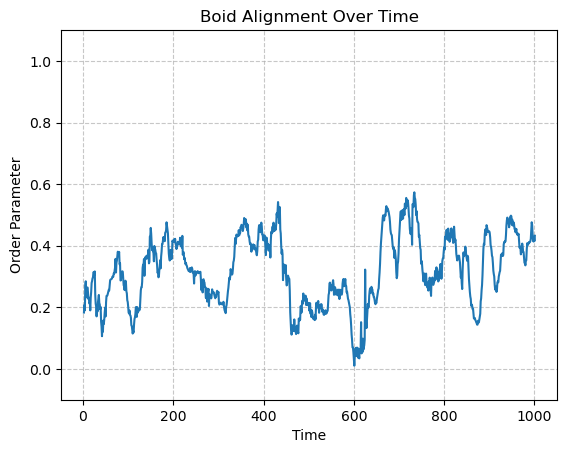

In [34]:
plt.plot(order_df['time'], order_df['order_parameter'])
plt.xlabel('Time')
plt.ylabel('Order Parameter')
plt.title('Boid Alignment Over Time')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.1, 1.1)
plt.show()

#### nearest-neighbor distances